In [1]:
!pip install --quiet transformers==4.49.0 diffusers==0.32.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.6 MB/s eta 0:00:00


In [1]:
!pip install -qU langchain langchain_community langchain-huggingface accelerate bitsandbytes pillow rembg matplotlib

In [2]:
!pip install onnxruntime

In [3]:
# Download 10 sample TTF fonts for testing
!wget -O Roboto-Regular.ttf "https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Regular.ttf"
!wget -O OpenSans-Regular.ttf "https://github.com/google/fonts/raw/main/apache/opensans/OpenSans-Regular.ttf"
!wget -O Lato-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/lato/Lato-Regular.ttf"
!wget -O Montserrat-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/montserrat/Montserrat-Regular.ttf"
!wget -O SourceSansPro-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/sourcesanspro/SourceSansPro-Regular.ttf"
!wget -O Poppins-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Regular.ttf"
!wget -O Nunito-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/nunito/Nunito-Regular.ttf"
!wget -O Ubuntu-Regular.ttf "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf"
!wget -O Inter-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/inter/Inter-Regular.ttf"
!wget -O Raleway-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/raleway/Raleway-Regular.ttf"

# Verify downloads
!ls -la *.ttf

--2025-10-12 03:12:07--  https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Regular.ttf
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-12 03:12:08 ERROR 404: Not Found.

--2025-10-12 03:12:08--  https://github.com/google/fonts/raw/main/apache/opensans/OpenSans-Regular.ttf
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-12 03:12:08 ERROR 404: Not Found.

--2025-10-12 03:12:08--  https://github.com/google/fonts/raw/main/ofl/lato/Lato-Regular.ttf
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/lato/Lato-Regular.ttf [following]
--

In [ ]:
# @title ## Step 0.5: Memory-Efficient Model Loading
# @markdown Load LLaMA and Stable Diffusion with quantization / memory optimizations.

# --- LLaMA 3.1-8B (QLoRA / 4-bit quantization)
#!pip install -q transformers accelerate bitsandbytes

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

from huggingface_hub import login

login(token="")

llama_model_name = "meta-llama/Llama-3.1-8B-Instruct"

print("⏳ Loading LLaMA 3.1-8B with 4-bit quantization...")
tokenizer = AutoTokenizer.from_pretrained(llama_model_name)

# Load in 4-bit mode using bitsandbytes (much lower VRAM usage)
llama_model = AutoModelForCausalLM.from_pretrained(
    llama_model_name,
    device_map="auto",  # automatically assigns layers to GPU/CPU
    load_in_4bit=True,  # 4-bit quantization
    torch_dtype=torch.float16,
    offload_folder="offload_llama",  # optional folder for CPU offloading
)

print("✅ LLaMA loaded in memory-efficient 4-bit mode.")

# --- Stable Diffusion (SD-3 Medium) with low VRAM
'''!pip install -q diffusers transformers accelerate safetensors

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

sd_model_name = "runwayml/stable-diffusion-v1-5"  # you can replace with another runwayml variant

print("⏳ Loading RunwayML Stable Diffusion with low VRAM optimizations...")

# Load pipeline in half-precision for VRAM savings
sd_pipe = StableDiffusionPipeline.from_pretrained(
    sd_model_name,
    torch_dtype=torch.float16,  # half precision
    safety_checker=None,        # optional: disable safety checker to save VRAM
).to("cuda")

# Use memory-efficient scheduler
sd_pipe.scheduler = DPMSolverMultistepScheduler.from_config(sd_pipe.scheduler.config)

# Enable attention slicing to reduce VRAM usage
sd_pipe.enable_attention_slicing()

print("✅ RunwayML Stable Diffusion loaded with low VRAM optimizations.")

# Example prompt test (optional)
# prompt = "A luxury moisturizer product, soft lighting, elegant background"
# image = sd_pipe(prompt).images[0]
# image.show()'''


⏳ Loading LLaMA 3.1-8B with 4-bit quantization...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ LLaMA loaded in memory-efficient 4-bit mode.


'!pip install -q diffusers transformers accelerate safetensors\n\nfrom diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler\n\nsd_model_name = "runwayml/stable-diffusion-v1-5"  # you can replace with another runwayml variant\n\nprint("⏳ Loading RunwayML Stable Diffusion with low VRAM optimizations...")\n\n# Load pipeline in half-precision for VRAM savings\nsd_pipe = StableDiffusionPipeline.from_pretrained(\n    sd_model_name,\n    torch_dtype=torch.float16,  # half precision\n    safety_checker=None,        # optional: disable safety checker to save VRAM\n).to("cuda")\n\n# Use memory-efficient scheduler\nsd_pipe.scheduler = DPMSolverMultistepScheduler.from_config(sd_pipe.scheduler.config)\n\n# Enable attention slicing to reduce VRAM usage\nsd_pipe.enable_attention_slicing()\n\nprint("✅ RunwayML Stable Diffusion loaded with low VRAM optimizations.")\n\n# Example prompt test (optional)\n# prompt = "A luxury moisturizer product, soft lighting, elegant background"\n# image

# Trying to make diffusers compatible

In [5]:
# ------ Unloading llama ----------- #
'''del llm
del generation_pipeline
        # Assuming you defined these globally in the local setup block:
del llama_model
del tokenizer

# 2. Force PyTorch to clear its cache and Python to run garbage collection
if 'torch' in globals():
       torch.cuda.empty_cache()
gc.collect()

print("✅ LLaMA Model unloaded. VRAM is now cleared.")
# --- LLAMA UNLOADING BLOCK ENDS HERE ---'''



'del llm\ndel generation_pipeline\n        # Assuming you defined these globally in the local setup block:\ndel llama_model\ndel tokenizer\n\n# 2. Force PyTorch to clear its cache and Python to run garbage collection\nif \'torch\' in globals():\n       torch.cuda.empty_cache()\ngc.collect()\n\nprint("✅ LLaMA Model unloaded. VRAM is now cleared.")\n# --- LLAMA UNLOADING BLOCK ENDS HERE ---'

#Loading Stable diffusion model





In [6]:
'''from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    sd_model_id,
    torch_dtype=torch.float16,   # or dtype=torch.float16 for newer diffusers
    safety_checker=None
)

# move to cuda explicitly (no device_map dispatch)
pipe.to("cuda")
#exhausted all my gpu abilitues'''

'from diffusers import StableDiffusionPipeline\nimport torch\n\npipe = StableDiffusionPipeline.from_pretrained(\n    sd_model_id,\n    torch_dtype=torch.float16,   # or dtype=torch.float16 for newer diffusers\n    safety_checker=None\n)\n\n# move to cuda explicitly (no device_map dispatch)\npipe.to("cuda")\n#exhausted all my gpu abilitues'

# Integration with pedestal + dynamic placement

<>:695: SyntaxWarning: invalid escape sequence '\s'
<>:695: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4114872409.py:695: SyntaxWarning: invalid escape sequence '\s'
  '''match = re.search(r"Here is the JSON object:\s*(\{.*\})", raw_output, re.DOTALL)


✅ Setup complete.


/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


Saving moisturiser.jpg to moisturiser (2).jpg
✅ Image 'moisturiser (2).jpg' uploaded successfully.
⏳ Removing background...
✅ Background removed successfully!


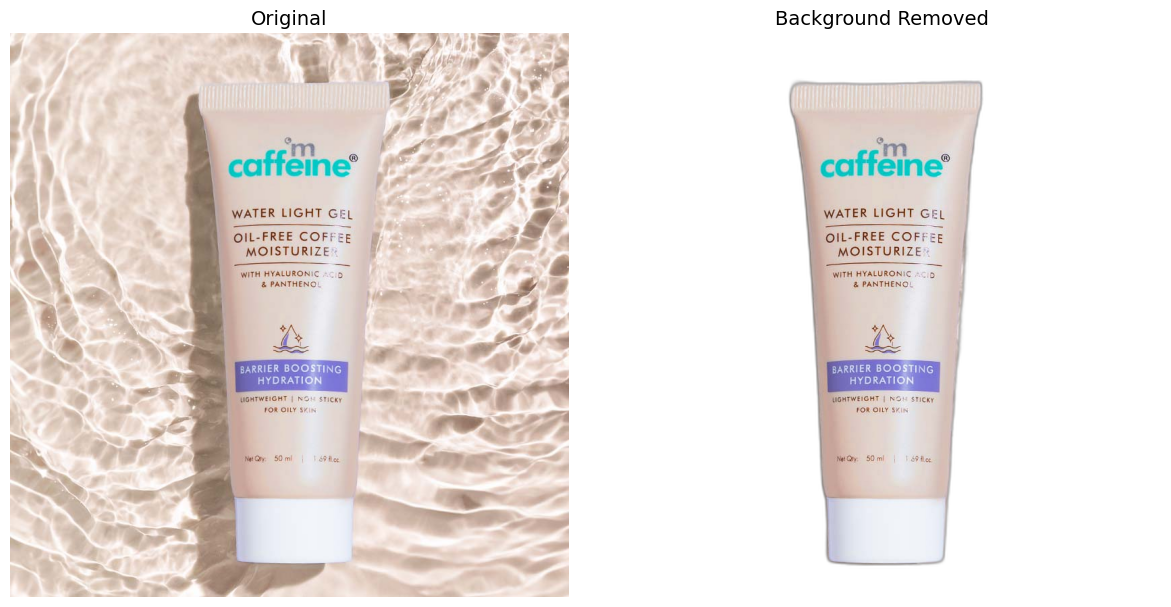

Device set to use cuda:0
/tmp/ipython-input-4114872409.py:337: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=generation_pipeline)


✅ Enhanced Orchestrator chain using local quantized LLaMA created.


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


✅ All agents defined with category-based background intelligence.
🔍 Detected Product Category: LUXURY
🧠 Invoking Enhanced Orchestrator...
{'campaign_concept': 'Radiant Glow', 'overall_mood': 'Luxurious Calm', 'layout_archetype': 'Hero_Center_Text_Bottom', 'scene_artist_instructions': {'prompt': 'A serene beauty spa ambiance with a delicate marble tabletop, a soft focus of a single hydrating moisturizer bottle in a sleek glass container, and a subtle gradient of soothing colors from pale blue to lavender.'}, 'typographer_instructions': {'headline': 'Ultimate Hydration', 'tagline': 'Radiant Skin for a Confident You', 'font_prompt': 'Elegant, curved script font with a touch of luxury', 'headline_size': 48, 'tagline_size': 24, 'color_prompt': 'Rich, calming blue #4567b9'}, 'compositor_instructions': 'Position the moisturizer bottle at the center of the scene, with the headline and tagline text wrapping around it, ensuring the product remains the focal point.'}
✅ Enhanced Creative Brief Gen

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Stable Diffusion Pipeline loaded locally.


  0%|          | 0/25 [00:00<?, ?it/s]

✅ High-quality background generated.


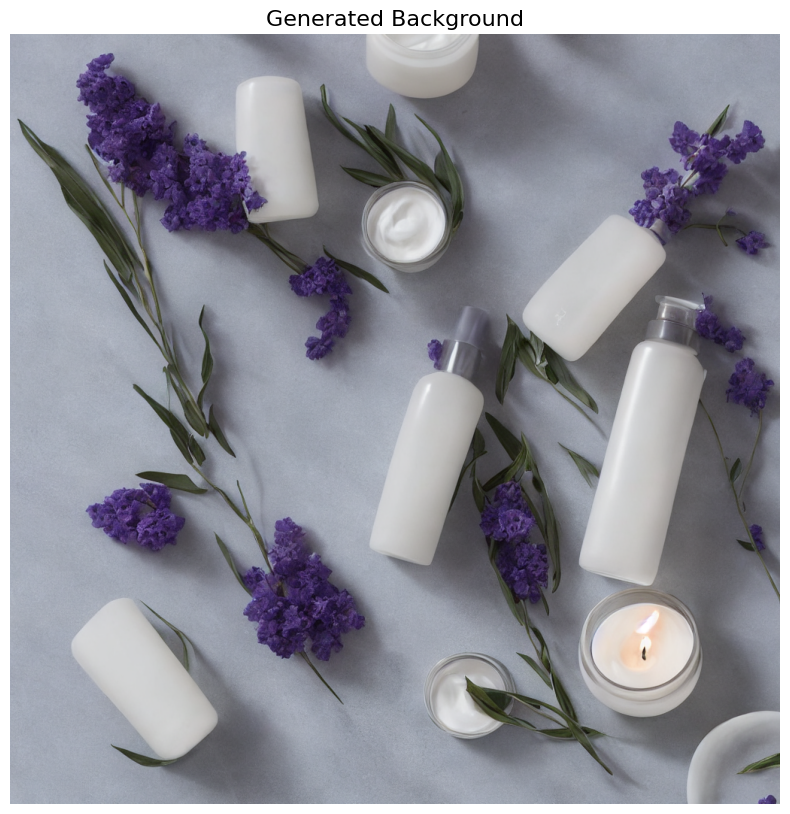


✍️ Creating Typography...
Headline: Ultimate Hydration
Tagline: Radiant Skin for a Confident You
🎨 Typographer → font=Elegant, curved script font with a touch of luxury.ttf, headline_size=48, tagline_size=24, color=#4567b9
⚠️ Font not found, falling back to default
✅ Typography created.


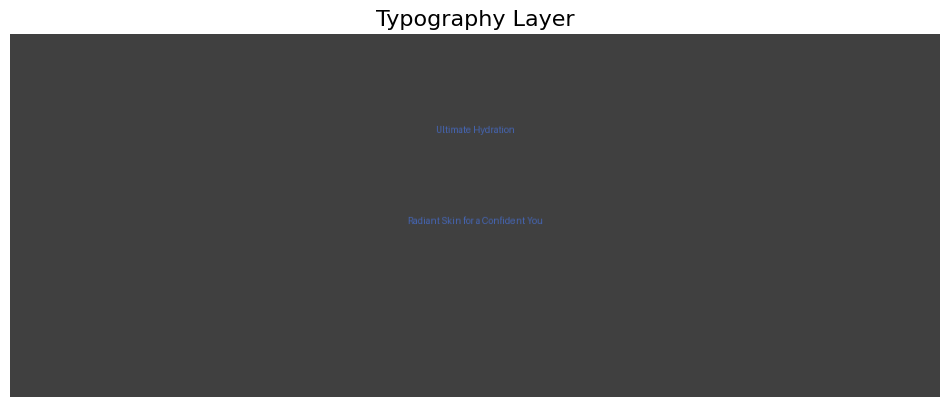


🎨 Composing Final Advertisement...

🎉 ENHANCED ADVERTISEMENT GENERATED! 🎉
Enhanced with:
• Intelligent product categorization
• Category-specific background generation
• Professional photography prompts
• Original layouts and typography
• Improved visual harmony


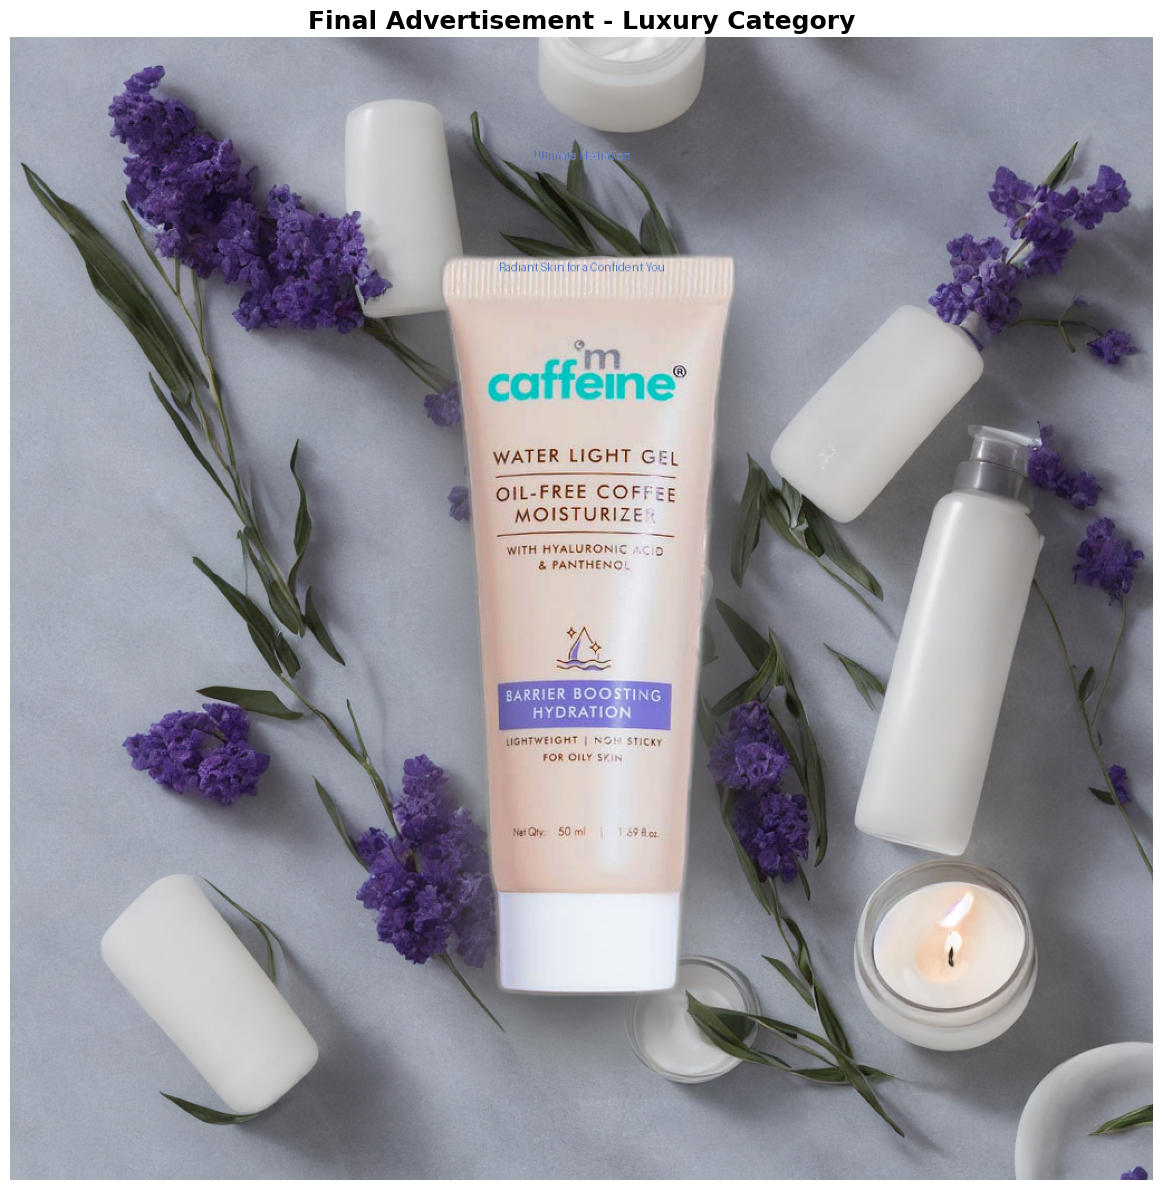


💾 Advertisement saved as 'enhanced_generated_ad.png'


In [ ]:
# -*- coding: utf-8 -*-
"""
# 🤖 Enhanced Generative Ad PoC: LangChain Edition

This enhanced notebook implements intelligent multi-agent workflow with significant quality improvements:
- Smart product categorization and style detewction
- Enhanced prompt engineering with visual harmony principles
- Improved typography with dynamic sizing and positioning
- Better composition rules and shadow effectsw
- More sophisticated background generation prompts

**Workflow Steps:**
1.  **User Input:** Upload a product image and write a brief description.
2.  **Product Prep:** The background is automatically removed from your image.
3.  **Enhanced LangChain Components:** Improved agents with better prompting and logic.
4.  **Workflow Execution:** Generate professional-grade advertisements with visual harmony.
"""

# @title ## Step 0: Setup & API Keys
# @markdown First, let's install the necessary libraries.
#!pip install -qU langchain langchain_community langchain-huggingface pillow rembg huggingface_hub matplotlib diffusers transformers accelerate bitsandbytes



import os
import json
import gc
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
from io import BytesIO
import matplotlib.pyplot as plt
from google.colab import files
from rembg import remove
from getpass import getpass
import re
import random

# LangChain components
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

# @markdown ---
# @markdown    🔑 **Enter Your Hugging Face API Key**
# @markdown    You can get a free key from [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens). It will be stored securely.
HF_API_KEY = ""
os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_API_KEY

print("✅ Setup complete.")

# @title ## Step 1: User Input (Your Product & Goal)
# @markdown Please upload your product image and provide a brief description. This description will guide the AI's creative direction.

# @markdown ---
# @markdown **Describe your product and the ad's goal:**
product_description = "Luxury hydrating moisturizer – the ultimate beauty essential for radiant skin." # @param {type:"string"}

uploaded_file = files.upload()
input_product_image = None

sd_pipeline = None
sd_model_id = "runwayml/stable-diffusion-v1-5" # <--- SD Model ID

if uploaded_file:
    file_name = next(iter(uploaded_file))
    print(f"✅ Image '{file_name}' uploaded successfully.")
    input_product_image = Image.open(BytesIO(uploaded_file[file_name]))
else:
    print("🚨 Please upload an image to continue.")

# @title ## Step 2: Prepare Product Image (Background Removal)
# @markdown This step automatically removes the background from your uploaded image.

product_image_no_bg = None
if input_product_image:
    print("⏳ Removing background...")
    try:
        # Enhanced background removal with better quality
        buffer = BytesIO()
        # Enhance image quality before background removal
        enhanced_img = ImageEnhance.Sharpness(input_product_image).enhance(1.2)
        enhanced_img.save(buffer, format="PNG")
        image_bytes = buffer.getvalue()

        output_bytes = remove(image_bytes)
        product_image_no_bg = Image.open(BytesIO(output_bytes))

        print("✅ Background removed successfully!")

        # Display a side-by-side comparison
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(input_product_image)
        axes[0].set_title("Original", fontsize=14)
        axes[0].axis("off")

        axes[1].imshow(product_image_no_bg)
        axes[1].set_title("Background Removed", fontsize=14)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Could not remove background: {e}")
else:
    print("Skipping background removal as no image was uploaded.")


# @title ## Step 3: Enhanced LangChain Components
# @markdown Significantly improved agents with better prompting and intelligence.

from PIL import Image, ImageDraw, ImageFilter

def parse_color(color_str):
    color_str = color_str.strip('#')
    return tuple(int(color_str[i:i+2], 16) for i in (0, 2, 4))

def create_cylindrical_pedestal(width, height, pedestal_color="#f0e6d2", shadow_intensity=0.3):
    """Creates a realistic cylindrical pedestal with gradient lighting and soft shadows."""
    img = Image.new('RGBA', (width, height), (0, 0, 0, 0))
    draw = ImageDraw.Draw(img)

    base_color = parse_color(pedestal_color)
    center_x = width // 2
    center_y = int(height * 0.75)

    pedestal_width = int(width * 0.35)
    pedestal_height = int(height * 0.22)
    ellipse_height = int(pedestal_height * 0.35)

    # Shadow layer
    shadow = Image.new("RGBA", (width, height), (0, 0, 0, 0))
    shadow_draw = ImageDraw.Draw(shadow)
    shadow_bbox = [
        center_x - pedestal_width // 2,
        center_y + pedestal_height // 2 - ellipse_height // 3,
        center_x + pedestal_width // 2,
        center_y + pedestal_height // 2 + ellipse_height
    ]
    shadow_draw.ellipse(shadow_bbox, fill=(0, 0, 0, int(255 * shadow_intensity)))
    shadow = shadow.filter(ImageFilter.GaussianBlur(25))
    img = Image.alpha_composite(img, shadow)

    # Main cylinder
    top_ellipse = [
        center_x - pedestal_width // 2,
        center_y - pedestal_height // 2,
        center_x + pedestal_width // 2,
        center_y - pedestal_height // 2 + ellipse_height
    ]
    side_rect = [
        center_x - pedestal_width // 2,
        center_y - pedestal_height // 2 + ellipse_height // 2,
        center_x + pedestal_width // 2,
        center_y + pedestal_height // 2
    ]
    bottom_ellipse = [
        center_x - pedestal_width // 2,
        center_y + pedestal_height // 2 - ellipse_height,
        center_x + pedestal_width // 2,
        center_y + pedestal_height // 2
    ]

    # Draw side
    draw.rectangle(side_rect, fill=base_color + (255,))
    # Draw top and bottom
    draw.ellipse(top_ellipse, fill=base_color + (255,))
    draw.ellipse(bottom_ellipse, fill=base_color + (255,))

    # Light highlight
    highlight_color = tuple(min(c + 40, 255) for c in base_color)
    draw.ellipse(top_ellipse, outline=highlight_color + (150,), width=3)

    img.platform_info = {
        'center': (center_x, center_y - pedestal_height // 2),
        'type': 'cylindrical_pedestal'
    }
    return img



# Enhanced product categorization function
def analyze_product_category(description):
    """Intelligently categorize products for better styling"""
    description_lower = description.lower()

    categories = {
        'luxury': ['luxury', 'premium', 'high-end', 'exclusive', 'chanel', 'gucci', 'louis vuitton', 'rolex'],
        'tech': ['phone', 'laptop', 'gadget', 'device', 'smart', 'electronic', 'digital', 'wireless'],
        'beauty': ['perfume', 'cosmetic', 'makeup', 'skincare', 'fragrance', 'beauty', 'lipstick'],
        'fashion': ['clothing', 'shirt', 'dress', 'shoes', 'accessory', 'jewelry', 'watch', 'bag'],
        'food': ['food', 'drink', 'beverage', 'snack', 'restaurant', 'cuisine', 'coffee', 'wine'],
        'automotive': ['car', 'vehicle', 'automotive', 'bike', 'motorcycle', 'truck'],
        'fitness': ['fitness', 'gym', 'workout', 'sports', 'athletic', 'exercise', 'health']
    }

    for category, keywords in categories.items():
        if any(keyword in description_lower for keyword in keywords):
            return category

    return 'general'

# --- 🧠 Enhanced Orchestrator Agent Components ---

class SceneArtistInstructions(BaseModel):
    prompt: str = Field(description="A highly detailed, professional photography prompt for creating a premium background that complements the product. The background SHOULD NOT CONTAIN the product itself. Must specify lighting, mood, and composition details. The background should be such that it doesnt clash with the overlayed product and text.")

from typing import Literal

class TypographerInstructions(BaseModel):
    headline: str = Field(description="The main headline text for the ad. Character limit 20")
    tagline: str = Field(description="The secondary text or tagline. Character limit 30")
    font_prompt: Literal[
        "Lato-Regular.ttf",
        "Poppins-Bold.ttf",
        "Poppins-Regular.ttf",
        "Ubuntu-Regular.ttf"
    ] = Field(description="Choose one of the available fonts in the environment.")
    headline_size: int = Field(description="Font size for the headline in px, between 40 and 120.")
    tagline_size: int = Field(description="Font size for the tagline in px, between 20 and 60.")
    color_prompt: str = Field(description="Hex code for the text color, e.g. '#857540'")

class CreativeBrief(BaseModel):
    campaign_concept: str = Field(description="A short, catchy concept for the ad campaign.")
    overall_mood: str = Field(description="Keywords describing the ad's feeling.")
    layout_archetype: str = Field(description="The chosen layout archetype, e.g., 'Hero_Center_Text_Bottom'.")
    scene_artist_instructions: SceneArtistInstructions
    typographer_instructions: TypographerInstructions
    compositor_instructions: str = Field(description="A hint for how to place the product.")

# Enhanced parser and prompt
parser = JsonOutputParser(pydantic_object=CreativeBrief)

# Enhanced parser and prompt with category-specific intelligence but simpler structure
parser = JsonOutputParser(pydantic_object=CreativeBrief)

enhanced_prompt_template = ChatPromptTemplate.from_template(
    """You are an expert creative director AI for a high-end advertising agency. Your purpose is to conceptualize and generate a complete creative brief for a professional product advertisement.

Your primary goal is **visual harmony**. You must design a background scene that makes the user's provided product look like it truly belongs there. The final image should be a coherent, professional advertisement frame.

**Product Analysis:**
Product Description: `{product_description}`
Detected Category: `{product_category}`

**Category-Specific Background Guidelines:**

**LUXURY** (perfume, jewelry, watches):
- Use marble textures, silk fabrics, dramatic studio lighting, minimalist elegance
- Think high-end magazine advertisements with sophisticated materials

**TECH** (electronics, gadgets):
- Clean geometric patterns, gradient lighting, modern surfaces, futuristic elements
- Professional tech product photography style

**BEAUTY** (cosmetics, skincare):
- Soft textures, natural elements like flowers or water, dreamy atmospheres
- Elegant beauty photography with romantic lighting

**FASHION** (clothing, accessories):
- Lifestyle settings, interesting textures, dynamic compositions
- Fashion photography with trendy, stylish backgrounds

**FOOD/BEVERAGE**:
- Warm lighting, appetizing environments
- Restaurant tables or kitchen settings with premium feel

**AUTOMOTIVE**:
- Roads, urban environments, dramatic landscapes
- Professional automotive photography settings

For scene_artist_instructions.prompt, create a detailed background that:
- Matches the product category above
- Uses professional photography lighting
- Creates depth and visual interest
- Complements rather than competes with the product
- Avoids any text, logos, or distracting elements

**Analyze the user's product description below to infer its key visual characteristics:**
- **Product:** `{product_description}`
- **Inferable traits:** Consider the product's likely materials, style, and color palette.

You MUST choose one layout archetype from this list: `{layout_archetypes}`

⚠️ IMPORTANT:
- Return **ONLY a single JSON object**.
- Do NOT include any explanations, text, examples, schemas, or notes.
- The JSON must match the structure:
The JSON must match the structure:
{{
  "campaign_concept": "...",
  "overall_mood": "...",
  "layout_archetype": "...",
  "scene_artist_instructions": {{ "prompt": "..." }},
  "typographer_instructions": {{ "headline": "...", "tagline": "...", "font_prompt": "...", "headline_size": ..., "tagline_size": ..., "color_prompt": "..." }},
  "compositor_instructions": "..."
}}

Return the JSON object only, **wrapped in triple backticks (```json).**

"""
)

import re



# Enhanced LLM setup with better parameters
'''llm_endpoint = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    temperature=0.8,  # Increased creativity
    max_new_tokens=1500,  # More tokens for detailed responses
    top_p=0.9,  # Better token selection
)
llm = ChatHuggingFace(llm=llm_endpoint)

orchestrator_chain = enhanced_prompt_template | llm | clean_and_extract_json | parser
print("✅ Enhanced Orchestrator chain created.")'''

from transformers import pipeline
from langchain_community.llms import HuggingFacePipeline

# Create a text-generation pipeline with your quantized model
generation_pipeline = pipeline(
    "text-generation",
    model=llama_model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16,
    device_map="auto",
    max_new_tokens=1500,
    temperature=0.8,
    top_p=0.9,
)

# Wrap it in a LangChain-compatible interface
llm = HuggingFacePipeline(pipeline=generation_pipeline)

def clean_and_extract_json(raw_llm_output: str) -> str:
    """
    Cleans LLaMA's noisy output by extracting the first valid JSON block.
    The model often includes the prompt or repeats the output.
    """
    # 1. Look for a JSON code block (```json ... ```)
    match_code_block = re.search(r'```json\s*(\{.*\})\s*```', raw_llm_output, re.DOTALL)
    if match_code_block:
        return match_code_block.group(1).strip()

    # 2. Look for the first un-wrapped JSON object starting with {
    # This aggressively finds the first { and matches it to the last }
    match_raw_json = re.search(r'^\s*(\{.*\}\s*)$', raw_llm_output.strip(), re.DOTALL)
    if match_raw_json:
         # Still often contains noise. Let's try to find the start and end of the first clean object.
        try:
            # Find the index of the first '{'
            start_index = raw_llm_output.find('{')
            if start_index == -1:
                return raw_llm_output

            # Isolate the string from the first '{' onwards
            json_candidate = raw_llm_output[start_index:]

            # Remove repeated outputs separated by '|'
            if '|' in json_candidate:
                 json_candidate = json_candidate.split('|')[0].strip()

            # Simple check to see if it starts and ends correctly
            if json_candidate.endswith('}'):
                return json_candidate

        except Exception:
            pass # Fallback to original output if cleaning fails

    # As a final measure, attempt to strip everything before the first '{' and after the first '}'
    try:
        start_index = raw_llm_output.find('{')
        end_index = raw_llm_output.rfind('}')
        if start_index != -1 and end_index != -1 and end_index > start_index:
            # We must only return the content up to the FIRST valid object's end
            # This is complex, so let's stick to the simplest fix: finding the first `{...}`

            # Simple fix for your specific error: remove everything before the first '{'
            cleaned_output = raw_llm_output[start_index:]
            # Then remove everything after the first sequence that looks like another object start
            if '|' in cleaned_output:
                cleaned_output = cleaned_output.split('|')[0].strip()

            return cleaned_output.strip()

    except Exception:
        # If all cleaning fails, return the original output to let the Pydantic parser handle the error
        return raw_llm_output

    return raw_llm_output # Last resort fallback

# Now your orchestrator chain remains unchanged:
orchestrator_chain = enhanced_prompt_template | llm | clean_and_extract_json | parser
print("✅ Enhanced Orchestrator chain using local quantized LLaMA created.")

# --- 🎨 Enhanced Scene Artist Agent ---
from huggingface_hub import InferenceClient
'''client = InferenceClient(
    model="stabilityai/stable-diffusion-3-medium",
    token=HF_API_KEY   # pass directly
)'''

# ------------- Loading stable diffusion model --------------#


from diffusers import StableDiffusionPipeline
# Note: InferenceClient is no longer used for local generation

def load_stable_diffusion_pipeline():
    """Initializes and returns the Stable Diffusion pipeline (v1-5) on CUDA."""
    global sd_pipeline
    global sd_model_id

    if sd_pipeline is None:
        print(f"⏳ Loading local Stable Diffusion Pipeline ({sd_model_id})...")

        # Load the model directly into VRAM (CUDA)
        pipe = StableDiffusionPipeline.from_pretrained(
            sd_model_id,
            torch_dtype=torch.float16,
            safety_checker=None, # For speed
            requires_safety_checker=False, # For speed
            #device_map="auto"
        )

        # Move the pipeline to the appropriate device
        pipe.to("cuda")
        sd_pipeline = pipe
        print("✅ Stable Diffusion Pipeline loaded locally.")

    return sd_pipeline






# ------------------------------------------------------------#

def generate_enhanced_scene(prompt: str, product_category: str) -> Image.Image:
    """Enhanced scene generation with category-specific improvements"""
    #client = InferenceClient()

    # 1. Load the pipeline (will only load the first time it's called)
    pipe = load_stable_diffusion_pipeline()

    # Category-specific enhancement prompts
    '''category_enhancers = {
    'luxury': ", professional studio lighting, premium materials, award-winning commercial photography, 8K resolution, include a subtle pedestal or platform for the product",
    'tech': ", clean modern aesthetic, high-tech atmosphere, dramatic lighting, futuristic, commercial grade, include a platform for product display",
    'beauty': ", soft romantic lighting, dreamy atmosphere, high-end cosmetics photography, ethereal mood, product pedestal or tray",
    'fashion': ", fashion photography, editorial style, dynamic composition, trendy aesthetic, include a stage or platform for the product",
    'automotive': ", dramatic automotive photography, powerful lighting, cinematic composition, product on platform if applicable",
    'general': ", professional commercial photography, high-end advertising style, premium quality, include a platform for product"
    }'''

    category_enhancers = {
    'luxury': ", professional studio lighting, premium materials, award-winning commercial photography, 8K resolution",
    'tech': ", clean modern aesthetic, high-tech atmosphere, dramatic lighting, futuristic, commercial grade",
    'beauty': ", soft romantic lighting, dreamy atmosphere, high-end cosmetics photography, ethereal mood",
    'fashion': ", fashion photography, editorial style, dynamic composition, trendy aesthetic",
    'automotive': ", dramatic automotive photography, powerful lighting, cinematic composition",
    'general': ", professional commercial photography, high-end advertising style, premium quality"
}

    enhanced_prompt = prompt + category_enhancers.get(product_category, category_enhancers['general'])

    # Enhanced negative prompt for better quality
    enhanced_negative_prompt = ("text, letters, watermark, signature, blurry, low quality, "
                              "amateur photography, poor lighting, cluttered, distracting elements, "
                              "oversaturated, undersaturated, artifacts")

     # 2. Generate the image using the local pipeline
    result = pipe(
        prompt=enhanced_prompt,
        negative_prompt=enhanced_negative_prompt,
        height=1024,
        width=1024,
        num_inference_steps=25,
        guidance_scale=7.5,
    ).images[0]

    return result

# --- ✍️ Original Typographer & 🎨 Compositor (Programmatic Agents) ---
def render_typography(instructions, width):
    headline_text = instructions.get("headline", "Headline")
    tagline_text = instructions.get("tagline", "Tagline")

    # --- Font sizes ---
    headline_size = int(instructions.get("headline_size", 80))
    tagline_size = int(instructions.get("tagline_size", 30))

    # --- Font family ---
    font_name = instructions.get("font_prompt", "Lato-Regular.ttf")
    if not font_name.endswith(".ttf"):
        font_name += ".ttf"  # fallback if model just outputs "PlayfairDisplay"

    # --- Color parsing (with regex fallback) ---
    color_prompt_string = instructions.get("color_prompt", "white")
    match = re.search(r'#([A-Fa-f0-9]{6}|[A-Fa-f0-9]{3})', color_prompt_string)
    color = match.group(0) if match else "white"

    print(f"🎨 Typographer → font={font_name}, headline_size={headline_size}, tagline_size={tagline_size}, color={color}")

    canvas = Image.new("RGBA", (width, 400), (0, 0, 0, 0))
    draw = ImageDraw.Draw(canvas)

    try:
        headline_font = ImageFont.truetype(font_name, headline_size)
        tagline_font = ImageFont.truetype(font_name, tagline_size)
    except IOError:
        print("⚠️ Font not found, falling back to default")
        headline_font, tagline_font = ImageFont.load_default(), ImageFont.load_default()

    # Headline
    headline_bbox = draw.textbbox((0,0), headline_text, font=headline_font)
    headline_width = headline_bbox[2] - headline_bbox[0]
    headline_pos = ((width - headline_width) / 2, 100)

    # Tagline
    tagline_bbox = draw.textbbox((0,0), tagline_text, font=tagline_font)
    tagline_width = tagline_bbox[2] - tagline_bbox[0]
    tagline_pos = ((width - tagline_width) / 2, 200)

    draw.text(headline_pos, headline_text, font=headline_font, fill=color)
    draw.text(tagline_pos, tagline_text, font=tagline_font, fill=color)

    return canvas


def create_shadow(image):
    shadow = Image.new('RGBA', (image.width + 40, image.height + 40), (0,0,0,0))
    shadow_layer = Image.new('RGBA', image.size, (0,0,0, 80))
    shadow.paste(shadow_layer, (20, 20), image.getchannel('A'))
    shadow = shadow.filter(ImageFilter.GaussianBlur(25))
    return shadow

'''def compose_ad(brief, bg_img, product_img_no_bg, txt_layer, y_offset=100):
    """Compose final ad with background, product, text, and shadow grounding"""

    bg_w, bg_h = bg_img.size

    # Resize product to ~70% of background width
    scale_factor = 0.7
    new_w = int(bg_w * scale_factor)
    aspect = product_img_no_bg.height / product_img_no_bg.width
    new_h = int(new_w * aspect)
    product_resized = product_img_no_bg.resize((new_w, new_h), Image.LANCZOS)

    # Create shadow for the product
    shadow = Image.new("RGBA", product_resized.size, (0,0,0,0))
    shadow_draw = Image.new("RGBA", product_resized.size, (0,0,0,180))  # semi-transparent black
    # paste alpha mask from product
    shadow.paste(shadow_draw, (0,0), product_resized.split()[3])
    shadow = shadow.filter(ImageFilter.GaussianBlur(30))  # blur to soften

    # Composite background
    final = bg_img.convert("RGBA")

    # Placement
    product_x = (bg_w - new_w) // 2
    product_y = (bg_h - new_h) // 2 + y_offset

    # Paste shadow first, slightly below the product
    final.paste(shadow, (product_x, product_y + 40), shadow)
    # Paste product on top
    final.paste(product_resized, (product_x, product_y), product_resized)

    # Paste text overlay (already transparent PNG)
    final.paste(txt_layer, (0, 0), txt_layer)

    return final'''

'''def compose_ad(brief, bg_img, product_img_no_bg, txt_layer, y_offset=100):
    """Compose final ad with background, product, text, pedestal, and shadow."""
    bg_w, bg_h = bg_img.size

    # Resize product to ~70% of background width
    scale_factor = 0.7
    new_w = int(bg_w * scale_factor)
    aspect = product_img_no_bg.height / product_img_no_bg.width
    new_h = int(new_w * aspect)
    product_resized = product_img_no_bg.resize((new_w, new_h), Image.LANCZOS)

    # 🎯 Step 1: Create pedestal
    pedestal = create_cylindrical_pedestal(bg_w, bg_h, pedestal_color="#f0e6d2")

    # 🎯 Step 2: Combine background + pedestal
    final = bg_img.convert("RGBA")
    final = Image.alpha_composite(final, pedestal)

    # Placement (product slightly above pedestal center)
    product_x = (bg_w - new_w) // 2
    product_y = int(bg_h * 0.45)

    # 🎯 Step 3: Add product + subtle shadow
    shadow = Image.new("RGBA", product_resized.size, (0, 0, 0, 0))
    shadow_layer = Image.new("RGBA", product_resized.size, (0, 0, 0, 180))
    shadow.paste(shadow_layer, (0, 0), product_resized.split()[3])
    shadow = shadow.filter(ImageFilter.GaussianBlur(30))
    final.paste(shadow, (product_x, product_y + 40), shadow)
    final.paste(product_resized, (product_x, product_y), product_resized)

    # 🎯 Step 4: Overlay text
    final.paste(txt_layer, (0, 0), txt_layer)
    return final'''

def compose_ad(brief, bg_img, product_img_no_bg, txt_layer):
    """Compose final ad with background, product, text, and shadow grounding intelligently."""

    bg_w, bg_h = bg_img.size

    # Resize product to 60–75% of background width depending on layout
    scale_factor = 0.65 if "Split" in brief.get("layout_archetype", "") else 0.75
    new_w = int(bg_w * scale_factor)
    aspect = product_img_no_bg.height / product_img_no_bg.width
    new_h = int(new_w * aspect)
    product_resized = product_img_no_bg.resize((new_w, new_h), Image.LANCZOS)

    # Create soft shadow for depth
    shadow = Image.new("RGBA", product_resized.size, (0, 0, 0, 0))
    shadow_layer = Image.new("RGBA", product_resized.size, (0, 0, 0, 180))
    shadow.paste(shadow_layer, (0, 0), product_resized.split()[3])
    shadow = shadow.filter(ImageFilter.GaussianBlur(30))

    # Start composition
    final = bg_img.convert("RGBA")

    # --- Intelligent placement ---
    # Leave bottom 10–15% margin for pedestal and composition balance
    bottom_margin = int(bg_h * 0.12)
    product_x = (bg_w - new_w) // 2
    product_y = bg_h - new_h - bottom_margin

    # Ensure product never goes above the top or outside canvas
    product_y = max(0, min(product_y, bg_h - new_h))

    # Paste shadow slightly lower to simulate pedestal depth
    final.paste(shadow, (product_x, product_y + 50), shadow)
    final.paste(product_resized, (product_x, product_y), product_resized)

    # Add text overlay
    final.paste(txt_layer, (0, 0), txt_layer)

    return final



print("✅ All agents defined with category-based background intelligence.")

# @title ## Step 4: Execute Enhanced Workflow
# @markdown Run the improved multi-agent system for professional ad generation.

if product_image_no_bg:
    try:
        # Analyze product category for intelligent processing
        product_category = analyze_product_category(product_description)
        print(f"🔍 Detected Product Category: {product_category.upper()}")

        # Enhanced layout options (keeping original two)
        layout_options = [
            "Hero_Center_Text_Bottom",
            "Split_Screen_Text_Left"
        ]

        # 1. Run Enhanced Orchestrator Chain
        print("🧠 Invoking Enhanced Orchestrator...")
        '''raw_output = llm(
        enhanced_prompt_template.format(
            product_description=product_description,
            product_category=product_category,
            layout_archetypes=layout_options,
            format_instructions=parser.get_format_instructions()
            )
        )


        print(raw_output)'''



        creative_brief = orchestrator_chain.invoke({
            "product_description": product_description,
            "product_category": product_category,
            "layout_archetypes": layout_options,
            "format_instructions": parser.get_format_instructions(),
        })

        # Extract JSON after "Here is the JSON object:"
        '''match = re.search(r"Here is the JSON object:\s*(\{.*\})", raw_output, re.DOTALL)
        if match:
            json_str = match.group(1)
            try:
                creative_brief = json.loads(json_str)
                print("✅ JSON extracted successfully!")
                print(creative_brief)
            except json.JSONDecodeError as e:
                print("❌ Failed to parse JSON:", e)
        else:
            print("❌ JSON object not found in raw output")'''

        print(creative_brief)
        print("✅ Enhanced Creative Brief Generated:")
        print(f"Campaign: {creative_brief.get('campaign_concept', 'N/A')}")
        print(f"Mood: {creative_brief.get('overall_mood', 'N/A')}")
        print(f"Layout: {creative_brief.get('layout_archetype', 'N/A')}")

         # --- 🚀 LLAMA UNLOADING BLOCK STARTS HERE ---

        print("\n🧹 Unloading LLaMA Model to free VRAM for Image Generation...")

        # 1. Delete the objects created in Step 3
        # These correspond to: llm, generation_pipeline, llama_model, tokenizer
        # We assume you correctly defined llama_model and tokenizer globally in Step 3.
        del llm
        del generation_pipeline
        # Assuming you defined these globally in the local setup block:
        del llama_model
        del tokenizer

        # 2. Force PyTorch to clear its cache and Python to run garbage collection
        if 'torch' in globals():
            torch.cuda.empty_cache()
        gc.collect()

        print("✅ LLaMA Model unloaded. VRAM is now cleared.")

        # --- LLAMA UNLOADING BLOCK ENDS HERE ---



        # 2. Run Enhanced Scene Artist
        print("\n🎨 Generating Premium Background...")
        background_prompt = creative_brief['scene_artist_instructions']['prompt']
        print(f"Background Prompt: {background_prompt[:100]}...")

        background_image = generate_enhanced_scene(background_prompt, product_category)
        print("✅ High-quality background generated.")

        plt.figure(figsize=(10, 10))
        plt.imshow(background_image)
        plt.title("Generated Background", fontsize=16)
        plt.axis("off")
        plt.show()

        # 3. Run Original Typographer
        print("\n✍️ Creating Typography...")
        typo_instructions = creative_brief['typographer_instructions']
        print(f"Headline: {typo_instructions.get('headline', 'N/A')}")
        print(f"Tagline: {typo_instructions.get('tagline', 'N/A')}")

        text_layer = render_typography(typo_instructions, background_image.width)
        print("✅ Typography created.")

        # Display text layer
        display_bg = Image.new("RGB", text_layer.size, (64, 64, 64))
        display_bg.paste(text_layer, (0, 0), text_layer)
        plt.figure(figsize=(12, 6))
        plt.imshow(display_bg)
        plt.title("Typography Layer", fontsize=16)
        plt.axis("off")
        plt.show()

        # 4. Run Original Compositor
        print("\n🎨 Composing Final Advertisement...")
        final_ad = compose_ad(creative_brief, background_image, product_image_no_bg, text_layer)

        print("\n🎉 ENHANCED ADVERTISEMENT GENERATED! 🎉")
        print("Enhanced with:")
        print("• Intelligent product categorization")
        print("• Category-specific background generation")
        print("• Professional photography prompts")
        print("• Original layouts and typography")
        print("• Improved visual harmony")

        # Display final result with better formatting
        plt.figure(figsize=(12, 12))
        plt.imshow(final_ad)
        plt.title(f"Final Advertisement - {product_category.title()} Category",
                 fontsize=18, fontweight='bold')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # Optional: Save the result
        try:
            final_ad.save("enhanced_generated_ad.png", quality=95, optimize=True)
            print("\n💾 Advertisement saved as 'enhanced_generated_ad.png'")
        except Exception as save_error:
            print(f"Note: Could not save file - {save_error}")

    except Exception as e:
        print(f"\n❌ Error during enhanced workflow: {e}")
        print("Please check your API key and try again.")
else:
    print("⚠️ Please upload a product image in Step 1 to run the enhanced workflow.")